# Purpose

- The purpose of this notebook is to study some properties of bootstrapping
- I will use a synthetically-generated Sc-RNAseq dataset


## Bootstrapping

Bootstrapping generally refers to statistical approach to quantifying uncertainty by re-using
the data, specifically random resampling with replacement.

Steps:

1. Sample the data with replacement. Sample size should be the same as the original data
2. From this bootstrapped sample, calculate the function/metric {f(i)} we want to calculate the bootstrapping statistic from (e.g. mean, median)
3. Repeat steps 1-2 multiple times (e.g. 1000 times) and store the metric each time
4. Use {f(1), ..., f(1000)} to calculate your goal statistic. For example, we can obtain bootstrap 95% confidence intervals by sorting the f(i) values from smallest to largest and taking the 50th and 1950th samples as estimates for the 0.25 and .975 quantiles, respectively.

Notes:

- the bootstrap is only useful when you can assume the sample itself contains variability equivalent to the variability you’d get by sampling new datasets from the same statistical model. So a sample from a 2-faced coin that was flipped 2 times with 2 heads, will not be useful to bootstrap.


# Import packages


In [1]:
import sys
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

sys.path.append("..")
from utils.functions.generate_sc_rnaseq_datasets import generate_scrnaseq_data

# Functions


In [2]:
def generate_bootstrap_calculate_mean(n_genes=2, n_cells=100):
    np.random.seed(111)

    # Get number of counts per UTR per cell to distribute multinomially
    data_ctrl = generate_scrnaseq_data(
        n_genes=n_genes,
        n_cells=n_cells,
        params_sequencing_depth={"mean": 1, "sd": 0.01},
        params_gene_means={"shape_gamma": 0.28, "rate_gamma": 0.26},
        params_gene_dispersion={"mean_norm": 1.2, "sd_norm": 1.15},
        percent_bimodal=10,
    )
    counts = data_ctrl.get("counts")

    # Perform bootstrap sampling for each gene
    n_bootstrap = 1000
    bootstrap_samples = {}

    for gene_idx in range(n_genes):
        gene_counts = counts[:, gene_idx]
        gene_bootstrap_samples = []
        for i in range(n_bootstrap):
            # Random sample with replacement
            bootstrap_sample = np.random.choice(
                gene_counts, size=len(gene_counts), replace=True
            )
            gene_bootstrap_samples.append(bootstrap_sample)
        bootstrap_samples[f"gene_{gene_idx + 1}"] = gene_bootstrap_samples

    # Calculate the mean for each bootstrap sample for each gene
    bootstrap_means = {}

    for gene_idx in range(n_genes):
        gene_key = f"gene_{gene_idx + 1}"
        gene_means = []
        for bootstrap_sample in bootstrap_samples[gene_key]:
            gene_means.append(np.mean(bootstrap_sample))
        bootstrap_means[gene_key] = gene_means

    return counts, bootstrap_samples, bootstrap_means

# Load data


In [3]:
np.random.seed(111)

n_genes = 2
n_cells = 100
# Get number of counts per UTR per cell to distribute multinomially
data_ctrl = generate_scrnaseq_data(
    n_genes=n_genes,
    n_cells=n_cells,
    params_sequencing_depth={"mean": 1, "sd": 0.01},
    params_gene_means={"shape_gamma": 0.28, "rate_gamma": 0.26},
    params_gene_dispersion={"mean_norm": 1.2, "sd_norm": 1.15},
    percent_bimodal=10,
)

data_ctrl.keys()

100%|██████████| 2/2 [00:00<00:00, 2232.20it/s]


dict_keys(['counts', 'counts_lognormalized', 'cell_data', 'gene_data'])

In [4]:
counts = data_ctrl.get("counts")
counts_normalized = data_ctrl.get("counts_lognormalized")
cell_data = data_ctrl.get("cell_data")
gene_data = data_ctrl.get("gene_data")

## Check data


In [5]:
counts

array([[ 0.,  0.],
       [ 2.,  0.],
       [ 1.,  0.],
       [ 0.,  0.],
       [ 1.,  0.],
       [ 1.,  1.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  1.],
       [ 0.,  1.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 1.,  0.],
       [ 1.,  1.],
       [ 1.,  0.],
       [ 0.,  0.],
       [ 1.,  0.],
       [ 0.,  1.],
       [ 2.,  0.],
       [ 0.,  0.],
       [ 1.,  0.],
       [ 6.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 1.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 2.,  0.],
       [ 1.,  0.],
       [ 0.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 2.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.],
       [ 1.,  0.],
       [ 1.,  0.],
       [ 2.,  0.],
       [ 1.,

In [6]:
counts_normalized

array([[-4.00000000e+00, -4.00000000e+00],
       [ 3.01051710e-01, -4.00000000e+00],
       [ 4.34272769e-05, -4.00000000e+00],
       [-4.00000000e+00, -4.00000000e+00],
       [ 4.34272769e-05, -4.00000000e+00],
       [ 4.34272769e-05,  4.34272769e-05],
       [-4.00000000e+00, -4.00000000e+00],
       [-4.00000000e+00, -4.00000000e+00],
       [-4.00000000e+00, -4.00000000e+00],
       [-4.00000000e+00,  4.34272769e-05],
       [-4.00000000e+00,  4.34272769e-05],
       [-4.00000000e+00, -4.00000000e+00],
       [-4.00000000e+00, -4.00000000e+00],
       [-4.00000000e+00, -4.00000000e+00],
       [ 4.34272769e-05, -4.00000000e+00],
       [ 4.34272769e-05,  4.34272769e-05],
       [ 4.34272769e-05, -4.00000000e+00],
       [-4.00000000e+00, -4.00000000e+00],
       [ 4.34272769e-05, -4.00000000e+00],
       [-4.00000000e+00,  4.34272769e-05],
       [ 3.01051710e-01, -4.00000000e+00],
       [-4.00000000e+00, -4.00000000e+00],
       [ 4.34272769e-05, -4.00000000e+00],
       [ 7.

In [7]:
display(cell_data.keys())
cell_data

dict_keys(['Cell', 'SequencingDepth', 'SumCounts', 'SumCountsNormalized', 'NonZeroCounts'])

{'Cell': array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
         66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
         79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
         92,  93,  94,  95,  96,  97,  98,  99, 100]),
 'SequencingDepth': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'SumCounts': array([ 0.,  2.,  1.,  0.,  1.,  2.,  0.,  0.,  0.,

In [8]:
display(gene_data.keys())
gene_data

dict_keys(['Gene', 'GeneDispersion', 'GeneMean', 'GeneMean2', 'BimodalProb', 'TrueMuSequencingDepth'])

{'Gene': array([1, 2]),
 'GeneDispersion': array([0.44243708, 1.45054387]),
 'GeneMean': array([0.66658544, 0.19846702]),
 'GeneMean2': array([0., 0.]),
 'BimodalProb': array([0., 0.]),
 'TrueMuSequencingDepth': [array([0.97480767, 1.33732652, 0.51718059, 0.27020162, 0.64412649,
         0.32789831, 0.29537798, 1.28411185, 0.26801451, 0.67807132,
         0.04078966, 0.76671765, 0.16264527, 0.42166203, 1.3004011 ,
         0.43809699, 0.49396046, 0.25016128, 0.38832376, 0.60572599,
         0.14741445, 0.75629697, 0.86481457, 1.41896105, 0.36221843,
         0.09101009, 0.75165237, 0.29176682, 0.22335929, 0.17160867,
         0.10431229, 0.41697695, 2.1211971 , 0.54742394, 1.02464575,
         0.64308013, 0.13122395, 0.07206356, 0.37609186, 1.37411159,
         0.17029747, 0.32718123, 0.33912017, 0.31798086, 0.48280004,
         0.45535563, 0.21335521, 0.05385033, 0.50531817, 0.52297039,
         0.60074133, 4.06090992, 1.40902244, 0.60286684, 0.28122662,
         0.27635907, 0.0650187

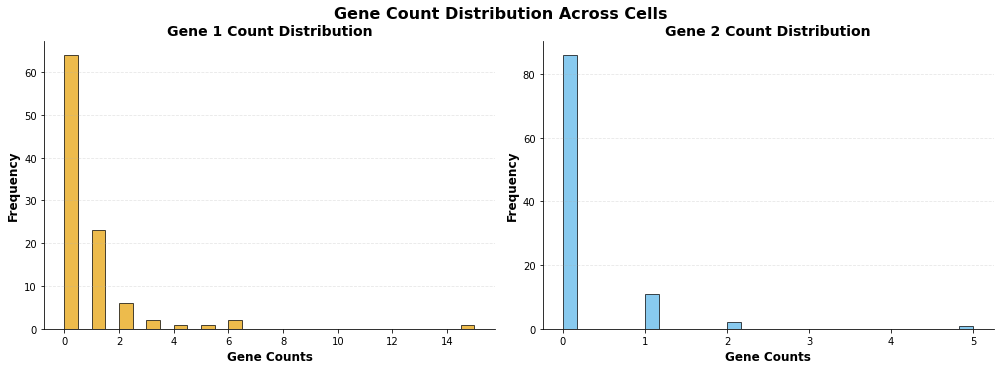

In [9]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define colors
colors = ["#E69F00", "#56B4E9"]
# Plot histogram for each gene
for i in range(n_genes):
    axes[i].hist(counts[:, i], bins=30, color=colors[i], edgecolor="black", alpha=0.7)
    axes[i].set_xlabel("Gene Counts", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Frequency", fontsize=12, fontweight="bold")
    axes[i].set_title(f"Gene {i+1} Count Distribution", fontsize=14, fontweight="bold")
    axes[i].grid(axis="y", alpha=0.3, linestyle="--")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.suptitle(
    "Gene Count Distribution Across Cells", fontsize=16, fontweight="bold", y=1.02
)
plt.show()

# Bootstrap


## Random sample with replacement


In [10]:
np.random.seed(111)

# Perform bootstrap sampling for each gene
n_bootstrap = 1000
bootstrap_samples = {}

for gene_idx in range(n_genes):
    gene_counts = counts[:, gene_idx]
    gene_bootstrap_samples = []
    for i in range(n_bootstrap):
        # Random sample with replacement
        bootstrap_sample = np.random.choice(
            gene_counts, size=len(gene_counts), replace=True
        )
        gene_bootstrap_samples.append(bootstrap_sample)
    bootstrap_samples[f"gene_{gene_idx + 1}"] = gene_bootstrap_samples

print(f"Number of genes: {len(bootstrap_samples)}")
print(f"Bootstrap samples per gene: {len(bootstrap_samples['gene_1'])}")
print(f"Each bootstrap sample has {len(bootstrap_samples['gene_1'][0])} cells")

Number of genes: 2
Bootstrap samples per gene: 1000
Each bootstrap sample has 100 cells


## Calculate metric


In [11]:
# Calculate the mean for each bootstrap sample for each gene
bootstrap_means = {}

for gene_idx in range(n_genes):
    gene_key = f"gene_{gene_idx + 1}"
    gene_means = []
    for bootstrap_sample in bootstrap_samples[gene_key]:
        gene_means.append(np.mean(bootstrap_sample))
    bootstrap_means[gene_key] = gene_means

print(f"Number of genes: {len(bootstrap_means)}")
print(f"Bootstrap means per gene: {len(bootstrap_means['gene_1'])}")
print(f"Example means for gene 1 (first 5): {bootstrap_means['gene_1'][:5]}")

Number of genes: 2
Bootstrap means per gene: 1000
Example means for gene 1 (first 5): [1.18, 0.68, 0.65, 0.75, 0.65]


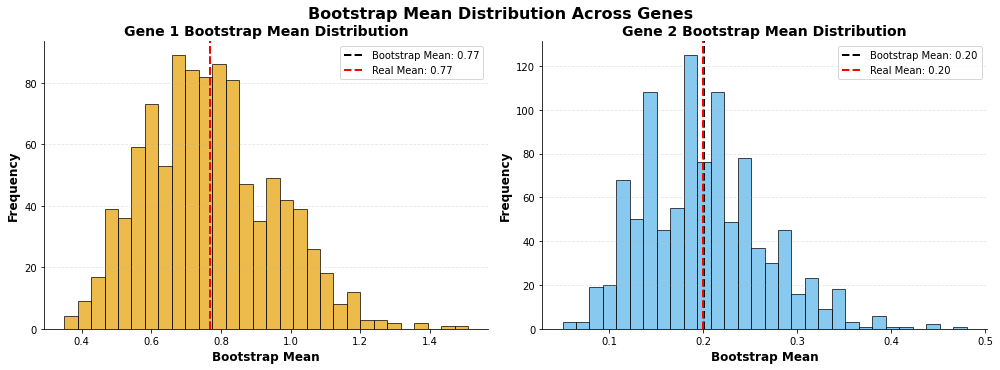

In [12]:
# Create figure with subplots for bootstrap means distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot histogram for each gene's bootstrap means
for i in range(n_genes):
    gene_key = f"gene_{i+1}"
    axes[i].hist(
        bootstrap_means[gene_key],
        bins=30,
        color=colors[i],
        edgecolor="black",
        alpha=0.7,
    )

    # Add vertical line for bootstrap means mean
    bootstrap_mean = np.mean(bootstrap_means[gene_key])
    axes[i].axvline(
        bootstrap_mean,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Bootstrap Mean: {bootstrap_mean:.2f}",
    )

    # Add vertical line for real sample mean
    real_mean = np.mean(counts[:, i])
    axes[i].axvline(
        real_mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Real Mean: {real_mean:.2f}",
    )

    axes[i].set_xlabel("Bootstrap Mean", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Frequency", fontsize=12, fontweight="bold")
    axes[i].set_title(
        f"Gene {i+1} Bootstrap Mean Distribution", fontsize=14, fontweight="bold"
    )
    axes[i].legend()
    axes[i].grid(axis="y", alpha=0.3, linestyle="--")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.suptitle(
    "Bootstrap Mean Distribution Across Genes", fontsize=16, fontweight="bold", y=1.02
)
plt.show()

- The bootstrapped samples mean closely matches the real sample mean
- **Their distribution gives us a measure of the possible variability when sampling the same X amount of cells from the population**


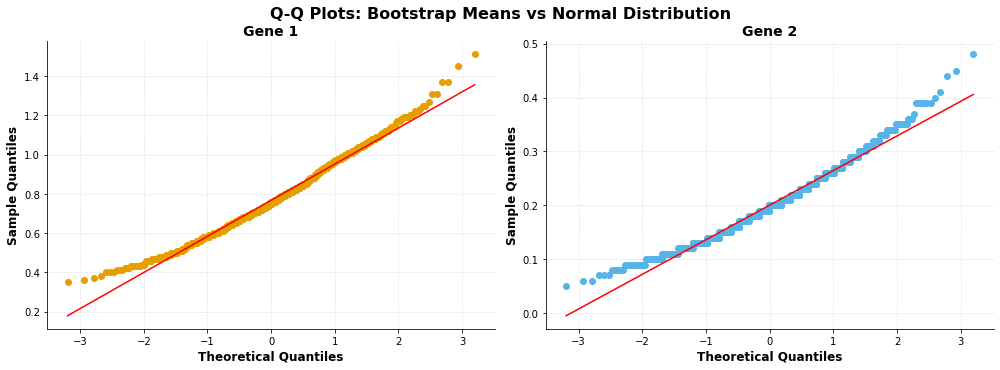

In [13]:
# Create figure with subplots for Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Import scipy for Q-Q plot calculations

# Create Q-Q plot for each gene's bootstrap means
for i in range(n_genes):
    gene_key = f"gene_{i+1}"

    # Create Q-Q plot
    stats.probplot(bootstrap_means[gene_key], dist="norm", plot=axes[i])

    axes[i].set_title(
        f"Gene {i+1}",
        fontsize=14,
        fontweight="bold",
    )
    axes[i].set_xlabel("Theoretical Quantiles", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Sample Quantiles", fontsize=12, fontweight="bold")
    axes[i].grid(alpha=0.3, linestyle="--")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

    # Customize the line color
    axes[i].get_lines()[0].set_markerfacecolor(colors[i])
    axes[i].get_lines()[0].set_markeredgecolor(colors[i])

# Adjust layout
plt.tight_layout()
plt.suptitle(
    "Q-Q Plots: Bootstrap Means vs Normal Distribution",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.show()

- Bootstrapped means follow a normal distribution except with shorter left data tail and larger right tail and a discrete distribution at lower counts
- This could be:
  - Underlying distribution (poisson with small lambda) is right-skewed, as seen from the original counts plots
    - Counts can't be negative, so at these small lambda (small mean counts) the real and bootstrap samples come with a truncated left-tail
  - Even though the CLT predicts that the means will converge to a normal distribution, at n=100 it may be too few cells


### Throubleshoot


In [14]:
n_genes_test = 2
n_cells_test = 10000
counts_test, bootstrap_samples_test, bootstrap_means_test = (
    generate_bootstrap_calculate_mean(n_genes=n_genes_test, n_cells=n_cells_test)
)

100%|██████████| 2/2 [00:00<00:00, 599.02it/s]


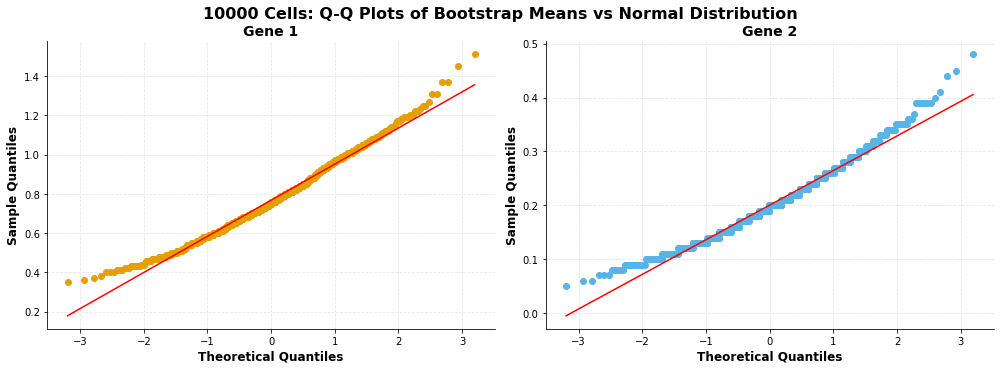

In [15]:
# Create figure with subplots for Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Import scipy for Q-Q plot calculations

# Create Q-Q plot for each gene's bootstrap means
for i in range(n_genes_test):
    gene_key = f"gene_{i+1}"

    # Create Q-Q plot
    stats.probplot(bootstrap_means[gene_key], dist="norm", plot=axes[i])

    axes[i].set_title(
        f"Gene {i+1}",
        fontsize=14,
        fontweight="bold",
    )
    axes[i].set_xlabel("Theoretical Quantiles", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Sample Quantiles", fontsize=12, fontweight="bold")
    axes[i].grid(alpha=0.3, linestyle="--")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

    # Customize the line color
    axes[i].get_lines()[0].set_markerfacecolor(colors[i])
    axes[i].get_lines()[0].set_markeredgecolor(colors[i])

# Adjust layout
plt.tight_layout()
plt.suptitle(
    f"{n_cells_test} Cells: Q-Q Plots of Bootstrap Means vs Normal Distribution",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.show()

In [16]:
n_genes_test = 2
n_cells_test = 10
counts_test, bootstrap_samples_test, bootstrap_means_test = (
    generate_bootstrap_calculate_mean(n_genes=n_genes_test, n_cells=n_cells_test)
)

100%|██████████| 2/2 [00:00<00:00, 3313.04it/s]


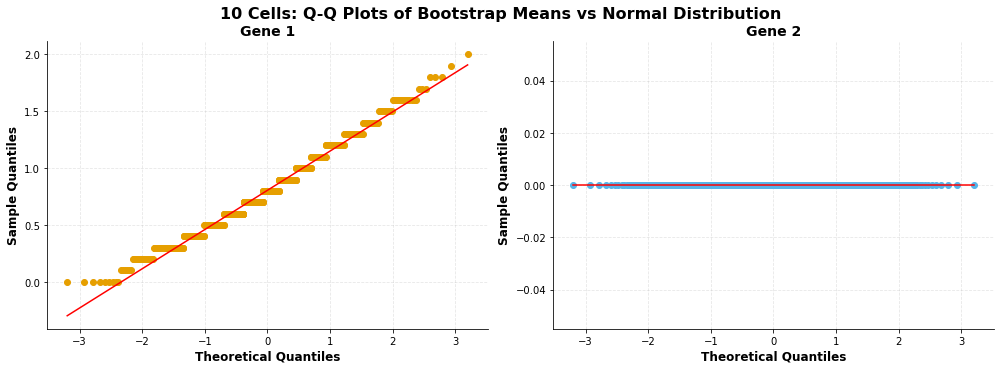

In [17]:
# Create figure with subplots for Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Import scipy for Q-Q plot calculations

# Create Q-Q plot for each gene's bootstrap means
for i in range(n_genes_test):
    gene_key = f"gene_{i+1}"

    # Create Q-Q plot
    stats.probplot(bootstrap_means_test[gene_key], dist="norm", plot=axes[i])

    axes[i].set_title(
        f"Gene {i+1}",
        fontsize=14,
        fontweight="bold",
    )
    axes[i].set_xlabel("Theoretical Quantiles", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Sample Quantiles", fontsize=12, fontweight="bold")
    axes[i].grid(alpha=0.3, linestyle="--")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

    # Customize the line color
    axes[i].get_lines()[0].set_markerfacecolor(colors[i])
    axes[i].get_lines()[0].set_markeredgecolor(colors[i])

# Adjust layout
plt.tight_layout()
plt.suptitle(
    f"{n_cells_test} Cells: Q-Q Plots of Bootstrap Means vs Normal Distribution",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.show()

- At 1000 cells the means indeed follow a normal distribution, as CLT predicts
- At 10 cells, the means have only discrete possibilities, and in lower counts' genes (gene 2) may end up with only 0s
  - Does not represent the variability of the sample and thereby not suited for bootstrapping


# Calculate the statistic of interest to estimate


# Confidence intervals

Lets start with the most common use for bootstrapping: Confidence intervals of the mean


In [18]:
# Calculate 95% confidence intervals for each gene's bootstrap means
bootstrap_ci = {}

for gene_idx in range(n_genes):
    gene_key = f"gene_{gene_idx + 1}"

    # Sort the bootstrap means
    sorted_means = np.sort(bootstrap_means[gene_key])

    # Calculate the 2.5th and 97.5th percentiles (95% CI)
    lower_bound = sorted_means[int(0.025 * n_bootstrap)]
    upper_bound = sorted_means[int(0.975 * n_bootstrap)]

    bootstrap_ci[gene_key] = {
        "lower": lower_bound,
        "upper": upper_bound,
        "mean": np.mean(bootstrap_means[gene_key]),
    }

# Print the results
for gene_idx in range(n_genes):
    gene_key = f"gene_{gene_idx + 1}"
    ci = bootstrap_ci[gene_key]
    real_mean = np.mean(counts[:, gene_idx])

    print(f"{gene_key.upper()}:")
    print(f"  Real Sample Mean: {real_mean:.4f}")
    print(f"  Bootstrap Mean: {ci['mean']:.4f}")
    print(f"  95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}]")
    print()

GENE_1:
  Real Sample Mean: 0.7700
  Bootstrap Mean: 0.7675
  95% CI: [0.4600, 1.1600]

GENE_2:
  Real Sample Mean: 0.2000
  Bootstrap Mean: 0.2003
  95% CI: [0.1000, 0.3400]



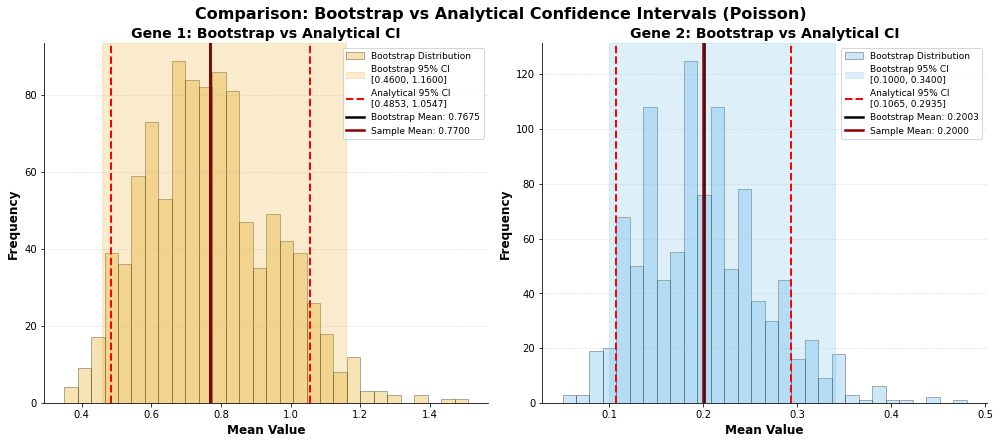

CONFIDENCE INTERVAL COMPARISON

GENE_1:
  Sample Mean: 0.7700

  Bootstrap Method:
    95% CI: [0.4600, 1.1600]
    CI Width: 0.7000

  Analytical Method (Poisson):
    95% CI: [0.4853, 1.0547]
    CI Width: 0.5694

  Difference in CI Width: 0.1306

GENE_2:
  Sample Mean: 0.2000

  Bootstrap Method:
    95% CI: [0.1000, 0.3400]
    CI Width: 0.2400

  Analytical Method (Poisson):
    95% CI: [0.1065, 0.2935]
    CI Width: 0.1870

  Difference in CI Width: 0.0530



In [19]:
# Calculate analytical confidence intervals assuming Negative Binomial distribution
# For Negative Binomial, variance = mean + (mean^2 / dispersion_parameter)
# CI = mean ± z * sqrt(variance/n)

# Z-score for 95% confidence interval
z_score = 1.96

analytical_ci = {}

for gene_idx in range(n_genes):
    gene_counts = counts[:, gene_idx]
    sample_mean = np.mean(gene_counts)
    sample_size = len(gene_counts)

    # Get dispersion parameter from gene_data
    gene_dispersion = gene_data["GeneDispersion"][gene_idx]

    # Calculate variance for Negative Binomial: mean + (mean^2 / dispersion)
    variance = sample_mean + (sample_mean**2) / gene_dispersion

    # Standard error for Negative Binomial: sqrt(variance/n)
    standard_error = np.sqrt(variance / sample_size)

    # Calculate CI
    lower = sample_mean - z_score * standard_error
    upper = sample_mean + z_score * standard_error

    analytical_ci[f"gene_{gene_idx + 1}"] = {
        "lower": lower,
        "upper": upper,
        "mean": sample_mean,
    }

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i in range(n_genes):
    gene_key = f"gene_{i+1}"

    # Extract CI values
    boot_lower = bootstrap_ci[gene_key]["lower"]
    boot_upper = bootstrap_ci[gene_key]["upper"]
    boot_mean = bootstrap_ci[gene_key]["mean"]

    anal_lower = analytical_ci[gene_key]["lower"]
    anal_upper = analytical_ci[gene_key]["upper"]
    anal_mean = analytical_ci[gene_key]["mean"]

    # Plot bootstrap distribution as histogram
    axes[i].hist(
        bootstrap_means[gene_key],
        bins=30,
        color=colors[i],
        alpha=0.3,
        edgecolor="black",
        label="Bootstrap Distribution",
    )

    # Add bootstrap CI as shaded region
    axes[i].axvspan(
        boot_lower,
        boot_upper,
        alpha=0.2,
        color=colors[i],
        label=f"Bootstrap 95% CI\n[{boot_lower:.4f}, {boot_upper:.4f}]",
    )

    # Add analytical CI as vertical lines
    axes[i].axvline(
        anal_lower,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Analytical 95% CI\n[{anal_lower:.4f}, {anal_upper:.4f}]",
    )
    axes[i].axvline(anal_upper, color="red", linestyle="--", linewidth=2)

    # Add means
    axes[i].axvline(
        boot_mean,
        color="black",
        linestyle="-",
        linewidth=2.5,
        label=f"Bootstrap Mean: {boot_mean:.4f}",
    )
    axes[i].axvline(
        anal_mean,
        color="darkred",
        linestyle="-",
        linewidth=2.5,
        label=f"Sample Mean: {anal_mean:.4f}",
    )

    axes[i].set_xlabel("Mean Value", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Frequency", fontsize=12, fontweight="bold")
    axes[i].set_title(
        f"Gene {i+1}: Bootstrap vs Analytical CI", fontsize=14, fontweight="bold"
    )
    axes[i].legend(fontsize=9, loc="upper right")
    axes[i].grid(axis="y", alpha=0.3, linestyle="--")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

plt.tight_layout()
plt.suptitle(
    "Comparison: Bootstrap vs Analytical Confidence Intervals (Poisson)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.show()

# Print comparison table
print("=" * 80)
print("CONFIDENCE INTERVAL COMPARISON")
print("=" * 80)
for gene_idx in range(n_genes):
    gene_key = f"gene_{gene_idx + 1}"
    boot_ci = bootstrap_ci[gene_key]
    anal_ci_vals = analytical_ci[gene_key]

    print(f"\n{gene_key.upper()}:")
    print(f"  Sample Mean: {anal_ci_vals['mean']:.4f}")
    print(f"\n  Bootstrap Method:")
    print(f"    95% CI: [{boot_ci['lower']:.4f}, {boot_ci['upper']:.4f}]")
    print(f"    CI Width: {boot_ci['upper'] - boot_ci['lower']:.4f}")
    print(f"\n  Analytical Method (Poisson):")
    print(f"    95% CI: [{anal_ci_vals['lower']:.4f}, {anal_ci_vals['upper']:.4f}]")
    print(f"    CI Width: {anal_ci_vals['upper'] - anal_ci_vals['lower']:.4f}")
    print(
        f"\n  Difference in CI Width: {abs((boot_ci['upper'] - boot_ci['lower']) - (anal_ci_vals['upper'] - anal_ci_vals['lower'])):.4f}"
    )
print("\n" + "=" * 80)

- In this comparison between analytical and bootstrapping methods to estimate confidence intervals, we note:
  - The analytical method is one based on the assumption of "normal" behaviour from the NB distributed sample. As we saw above this is not correct for our samples. As such we find that the intervals are symmetric and smaller, specially for the longer right data tail
  - Note also that for the analytical method we need to estimate the dispersion parameter for the NB. In this case we had the exact parameter used to generate the data, so the estimates were closer to reality than in usual cases
  - The bootstrapping method provides a closer approximation to the "exact" CI, with non-symmetrical intervals reflecting on the skewedness of the data


# More complex statistics


## DGE

Instead of bootstrapping gene expressions of each cell, we now bootstrap the entire cells
